In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print(train.shape)
print(test.shape)
train.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [214]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [215]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [216]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [217]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [218]:
train['Electrical']

,Electrical
0,SBrkr
1,SBrkr
2,SBrkr
3,SBrkr
4,SBrkr
...,...
1455,SBrkr
1456,SBrkr
1457,SBrkr
1458,FuseA


In [219]:
none_cols=['PoolQC', 'MiscFeature', 'Alley', 'Fence','FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'BsmtQual', 'BsmtCond', 'MasVnrType']
for col in none_cols:
  train[col]=train[col].fillna('None')
  test[col]=test[col].fillna('None')

In [220]:
train["LotFrontage"] = train["LotFrontage"].fillna(train["LotFrontage"].median())
test["LotFrontage"] = test["LotFrontage"].fillna(test["LotFrontage"].median())

train["GarageYrBlt"] = train["GarageYrBlt"].fillna(train["GarageYrBlt"].median())
test["GarageYrBlt"] = test["GarageYrBlt"].fillna(test["GarageYrBlt"].median())

train["MasVnrArea"] = train["MasVnrArea"].fillna(train["MasVnrArea"].median())
test["MasVnrArea"] = test["MasVnrArea"].fillna(test["MasVnrArea"].median())

train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])
test["Electrical"] = test["Electrical"].fillna(test["Electrical"].mode()[0])

In [221]:
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 3937.5
Upper Bound: 340037.5


In [222]:
outliers = train[(train["SalePrice"] < lower) | (train["SalePrice"] > upper)]

print("Outlier sayı:", len(outliers))
outliers.head()

Outlier sayı: 61


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,12,60,RL,85.0,11924,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,7,2006,New,Partial,345000
53,54,20,RL,68.0,50271,Pave,None,IR1,Low,AllPub,...,0,None,None,None,0,11,2006,WD,Normal,385000
58,59,60,RL,66.0,13682,Pave,None,IR2,HLS,AllPub,...,0,None,None,None,0,10,2006,New,Partial,438780
112,113,60,RL,77.0,9965,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,10,2007,New,Partial,383970
151,152,20,RL,107.0,13891,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,1,2008,New,Partial,372402


In [223]:
outliers = train[(train["SalePrice"] < lower) | (train["SalePrice"] > upper)]

outliers[["Id","SalePrice","OverallQual","GrLivArea","LotArea","YearBuilt"]].sort_values("SalePrice", ascending=False)

,Id,SalePrice,OverallQual,GrLivArea,LotArea,YearBuilt
691,692,755000,10,4316,21535,1994
1182,1183,745000,10,4476,15623,1996
1169,1170,625000,10,3627,35760,1995
898,899,611657,9,2364,12919,2009
803,804,582933,9,2822,13891,2008
...,...,...,...,...,...,...
990,991,348000,8,2392,9452,1997
642,643,345000,8,2704,13860,1972
11,12,345000,9,2324,11924,2005
320,321,342643,9,2596,16259,2006


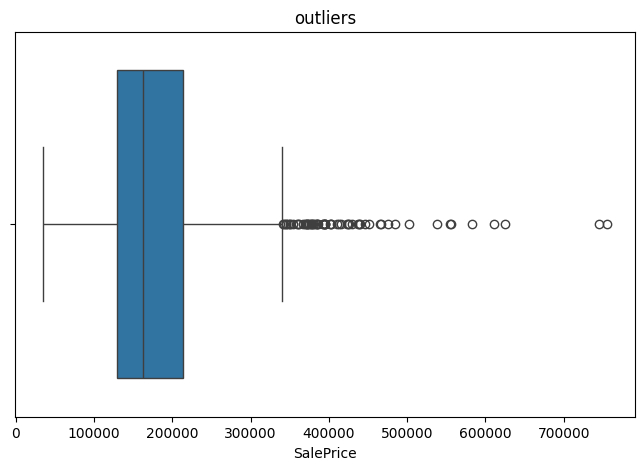

In [224]:
plt.figure(figsize=(8,5))
sns.boxplot(x=train["SalePrice"])
plt.title("outliers")
plt.show()

In [225]:
train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,None,IR1,Bnk,AllPub,...,0,None,None,None,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,None,IR3,Bnk,AllPub,...,480,Gd,None,None,0,1,2008,New,Partial,160000


In [226]:
train=train.drop(train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index)

In [227]:
print(train.shape)

(1458, 81)


In [228]:
X=train.drop('SalePrice',axis=1)
y=train['SalePrice']

In [229]:
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,0,None,None,None,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,0,None,MnPrv,None,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,0,None,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,0,None,None,None,0,4,2010,WD,Normal


In [230]:
categorical_cols=X.select_dtypes(include='object').columns
categorical_cols


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [231]:
numerical_cols=X.select_dtypes(exclude='object').columns
numerical_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [232]:
all_data = pd.concat([X, test], axis=0)

In [233]:
all_data = pd.get_dummies(all_data, drop_first=True)

In [234]:
X = all_data.iloc[:len(train), :]
test_processed = all_data.iloc[len(train):, :]

In [235]:
print(X.shape)
print(test_processed.shape)

(1458, 259)
(1459, 259)


In [236]:
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)

In [237]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001, random_state=42)

lasso.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.079e+11, tolerance: 7.594e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.001, random_state=42)

In [238]:
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Lasso

lasso.fit(X_train, y_train)

y_train_pred = lasso.predict(X_train)
y_valid_pred = lasso.predict(X_valid)

lasso_train_rmse = root_mean_squared_error(y_train, y_train_pred)
lasso_valid_rmse = root_mean_squared_error(y_valid, y_valid_pred)

print(lasso_train_rmse)
print(lasso_valid_rmse)

18883.776994036692
29983.137136850437


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.079e+11, tolerance: 7.594e+08
  model = cd_fast.enet_coordinate_descent(


In [239]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

rf = RandomForestRegressor(n_estimators=200,random_state=42)

rf.fit(X_train, y_train)


y_train_pred = rf.predict(X_train)
y_valid_pred = rf.predict(X_valid)


rf_train_rmse = root_mean_squared_error(y_train, y_train_pred)
rf_valid_rmse = root_mean_squared_error(y_valid, y_valid_pred)


print( rf_train_rmse)
print( rf_valid_rmse)

10578.120605321747
24465.640506761585


In [240]:
!pip install xgboost

In [241]:
from xgboost import XGBRegressor

In [242]:
xgb = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,random_state=42)

In [243]:
from sklearn.metrics import root_mean_squared_error

xgb.fit(X_train, y_train)

y_train_pred = xgb.predict(X_train)
y_valid_pred = xgb.predict(X_valid)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
valid_rmse = root_mean_squared_error(y_valid, y_valid_pred)

print("XGBoost Train RMSE:", train_rmse)
print("XGBoost Validation RMSE:", valid_rmse)

XGBoost Train RMSE: 9020.216796875
XGBoost Validation RMSE: 20989.330078125


In [244]:
results = {"Model": ["Lasso", "Random Forest", "XGBoost"],

           "Validation RMSE": [lasso_valid_rmse , rf_valid_rmse, valid_rmse]}

results = pd.DataFrame(results)
results.sort_values("Validation RMSE")

,Model,Validation RMSE
2,XGBoost,20989.330078
1,Random Forest,24465.640507
0,Lasso,29983.137137


In [245]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor


In [246]:
stack = StackingRegressor(
    estimators=[
        ("lasso", lasso),
        ("rf", rf),
        ("xgb", xgb)],
    final_estimator=Ridge()
)


In [247]:
stack.fit(X_train, y_train)
stack_train_pred = stack.predict(X_train)
stack_valid_pred = stack.predict(X_valid)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.079e+11, tolerance: 7.594e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.581e+11, tolerance: 6.043e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.496e+11, tolerance: 6.181e

In [248]:
from sklearn.metrics import root_mean_squared_error

stack_train_rmse = root_mean_squared_error(y_train, stack_train_pred)
stack_valid_rmse = root_mean_squared_error(y_valid, stack_valid_pred)

print("Stacking Train RMSE:", stack_train_rmse)
print("Stacking Validation RMSE:", stack_valid_rmse)

Stacking Train RMSE: 11244.30955023886
Stacking Validation RMSE: 20784.50123698407


In [249]:
results = pd.DataFrame({"Model": ["Lasso", "Random Forest", "XGBoost", "Stacking"],
"Validation RMSE": [lasso_valid_rmse,rf_valid_rmse,valid_rmse,stack_valid_rmse]})

results = results.sort_values("Validation RMSE")
print(results)

           Model  Validation RMSE
3       Stacking     20784.501237
2        XGBoost     20989.330078
1  Random Forest     24465.640507
0          Lasso     29983.137137


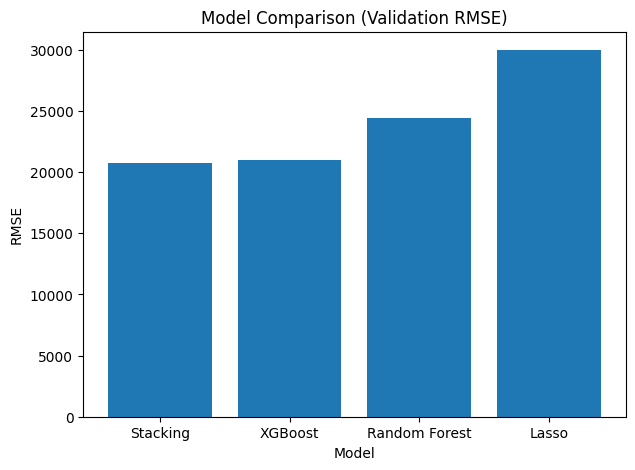

In [250]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["Validation RMSE"])
plt.title("Model Comparison (Validation RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

In [251]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kfold = KFold(n_splits=5,shuffle=True,random_state=42)

In [252]:
scores = cross_val_score(stack,X,y,
    cv=kfold,
    scoring="neg_root_mean_squared_error")

rmse_scores = -scores

print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.079e+11, tolerance: 7.594e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.671e+11, tolerance: 6.323e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.603e+11, tolerance: 6.057e

Fold RMSE: [20674.62978951 23828.06586163 21843.61037902 26254.95139782
 22563.32438288]
Mean RMSE: 23032.916362171625
Std RMSE: 1908.4157515994762


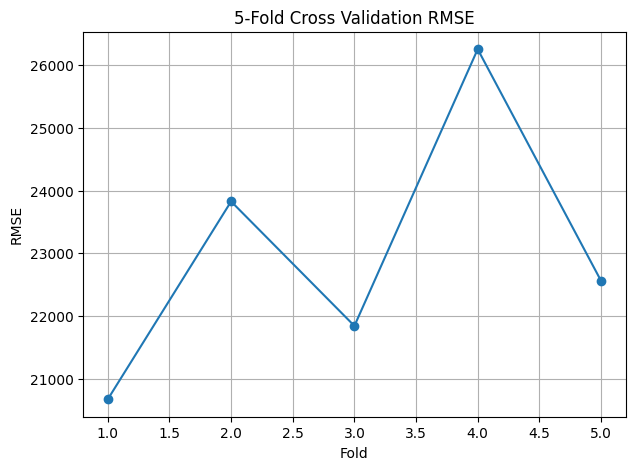

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(range(1, 6), rmse_scores, marker='o')
plt.title("5-Fold Cross Validation RMSE")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [254]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({"Feature": X_train.columns,
  "Importance": rf.feature_importances_})

importance = importance.sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
4,OverallQual,0.560437
16,GrLivArea,0.119754
12,TotalBsmtSF,0.059943
13,1stFlrSF,0.027186
9,BsmtFinSF1,0.026341
14,2ndFlrSF,0.021475
27,GarageArea,0.018693
23,TotRmsAbvGrd,0.013590
3,LotArea,0.012005
19,FullBath,0.011454


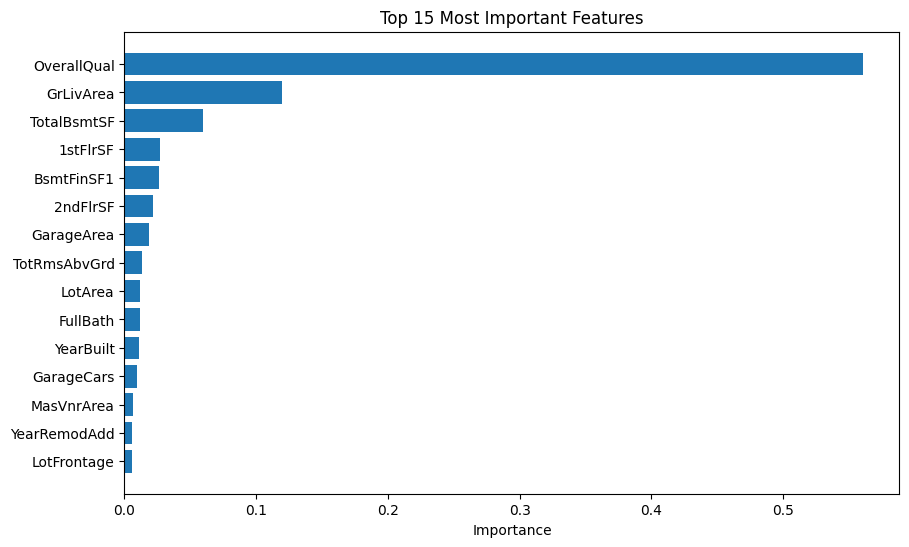

In [255]:
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"][:15],
  importance["Importance"][:15])

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

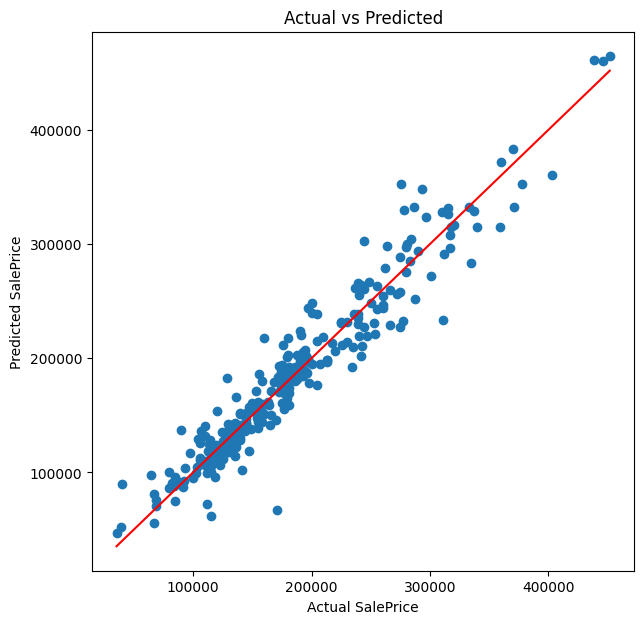

In [256]:
stack_pred = stack.predict(X_valid)

plt.figure(figsize=(7,7))

plt.scatter(y_valid, stack_pred)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    color="red"
)

plt.show()

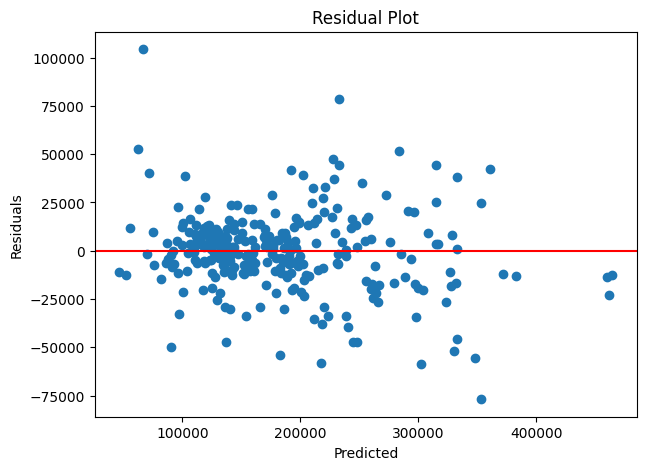

In [257]:
residuals = y_valid - stack_pred

plt.figure(figsize=(7,5))

plt.scatter(stack_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [260]:
results = pd.DataFrame({
    "Model": ["Lasso", "Random Forest", "XGBoost", "Stacking"],
    "Validation RMSE": [
        lasso_valid_rmse,
        rf_valid_rmse,
        valid_rmse,
        stack_valid_rmse
    ]
})

results = results.sort_values("Validation RMSE")

results

,Model,Validation RMSE
3,Stacking,20784.501237
2,XGBoost,20989.330078
1,Random Forest,24465.640507
0,Lasso,29983.137137


# Conclusion

In this project, house prices were predicted using ensemble learning techniques.

The dataset was cleaned by handling missing values and analyzing outliers.

Three base models (Lasso, Random Forest, XGBoost) were trained.

Finally, a Stacking Ensemble model achieved the best performance with the lowest Validation RMSE.

